In [1]:
from matchms.importing import load_from_msp, load_from_mgf
from matchms.exporting import save_as_mgf
import matchms.filtering as msfilters
from tqdm import tqdm

from matchms import set_matchms_logger_level
set_matchms_logger_level("ERROR")

In [2]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib_venn import venn3
import venn

from rdkit.Chem.rdinchi import InchiToInchiKey
from rdkit.Chem import MolFromSmiles
from rdkit.Chem.rdinchi import MolToInchiKey

In [3]:
# paths to spectra
wfsr_lib = "../../../../DATASETS/WFSR_Library_External_V3.25_MLready.msp"
mb_orbi = "../../../../DATASETS/massbank_OnlyOrbitrap_20250408.msp"
mb_tof = "../../../../DATASETS/massbank_OnlyTOF_20250408.msp"
gnps_pesticides = "../../../../DATASETS/GNPS-COLLECTIONS-PESTICIDES-POSITIVE.mgf"
gnps_sciex = "../../../../DATASETS/GNPS-SCIEX-LIBRARY.mgf"

In [4]:
gnps_pesticides_inchikeys = []
gnps_pesticides_spec = []
for spec in load_from_mgf(gnps_pesticides):
    if not spec.get("precursor_mz"):
        continue
    inchikey = spec.get("inchikey")
    if inchikey:
        gnps_pesticides_inchikeys.append(inchikey[:14])
        gnps_pesticides_spec.append(spec)
    elif spec.get("inchi"):
        inchi = spec.get("inchi")
        if inchi:
            inchikey = InchiToInchiKey(inchi)
            spec.set("inchikey", inchikey)
            gnps_pesticides_inchikeys.append(inchikey[:14])
            gnps_pesticides_spec.append(spec)
    else:
        smiles = spec.get("smiles")
        if smiles:
            mol = MolFromSmiles(smiles)
            inchikey = MolToInchiKey(mol)
            spec.set("inchikey", inchikey)
            gnps_pesticides_inchikeys.append(inchikey[:14])
            gnps_pesticides_spec.append(spec)
        else:
            print(spec.metadata)
        
print(len(set(gnps_pesticides_inchikeys)))

171


In [6]:
gnps_sciex_inchikeys = []
gnps_sciex_spec = []
for spec in load_from_mgf(gnps_sciex):
    if not spec.get("precursor_mz"):
        continue
    inchikey = spec.get("inchikey")
    if inchikey:
        gnps_sciex_inchikeys.append(inchikey[:14])
        gnps_sciex_spec.append(spec)
    else:
        inchi = spec.get("inchi").replace('"','')
        if inchi:
            inchikey = InchiToInchiKey(inchi)
            spec.set("inchikey", inchikey)
            gnps_sciex_inchikeys.append(inchikey[:14])
            gnps_sciex_spec.append(spec)
        else:
            print(spec.metadata)
print(len(set(gnps_sciex_inchikeys)))

309


---

In [7]:
wfsr_inchikeys = []
wfsr_spec = []
for spec in load_from_msp(wfsr_lib):
    if not spec.get("precursor_mz"):
        continue
    inchikey = spec.get("inchikey")
    if inchikey:
        wfsr_inchikeys.append(inchikey[:14])
        wfsr_spec.append(spec)
    else:
        print(spec.metadata)

In [8]:
massbank_inchikeys_orbi = []
massbank_spec_orbi = []
for spec in tqdm(load_from_msp(mb_orbi)):
    if not spec.get("precursor_mz"):
        continue
    inchikey = spec.get("inchikey")
    if inchikey:
        massbank_inchikeys_orbi.append(inchikey[:14])
        massbank_spec_orbi.append(spec)
    else:
        inchi = spec.get("inchi")
        if inchi:
            inchikey = InchiToInchiKey(inchi)
            spec.set("inchikey", inchikey)
            massbank_inchikeys_orbi.append(inchikey[:14])
            massbank_spec_orbi.append(spec)
        else:
            print(spec.metadata)

13656it [00:05, 2395.70it/s]

{'formula': 'C18H21ClN2O', 'instrument': 'Q Exactive Plus Orbitrap Thermo Scientific', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-Eawag_Additional_Specs-ET010101; origin=MassBank; Annotation Tentative identification: substance class known (Level 3); INTERNAL_ID 101', 'splash': 'splash10-014i-0009000000-6b6c6de087e1c9ad671e', 'num_peaks': '12', 'compound_name': 'CLC_317.1417_14.6', 'precursor_mz': 317.1415, 'adduct': '[M+H]+', 'retention_time': 870.0, 'instrument_type': 'LC-ESI-QFT'}
{'formula': 'C18H21ClN2O', 'instrument': 'Q Exactive Plus Orbitrap Thermo Scientific', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-Eawag_Additional_Specs-ET010102; origin=MassBank; Annotation Tentative identification: substance class known (Level 3); INTERNAL_ID 101', 'splash': 'splash10-0udl-1192000000-2e1124f2124d4e765271', 'num_peaks': '38', 'compound_name': 'CLC_317.1417_14.6', 'precursor_mz': 317.1415, 'adduct': '[M+H]+', 'retention_time': 870.0, 'instrument_type': 'LC-ESI-QFT'}
{'formula': 'C18H21C

14246it [00:05, 2571.22it/s]

{'formula': 'C12H13N3O5S', 'instrument': 'Q-Exactive + Thermo Scientific', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-Eawag_Additional_Specs-ET310401; origin=MassBank; Annotation Tentative identification: molecular formula only (Level 4); ALGAE_TP_ID 3104', 'splash': 'splash10-03di-0219000000-4a4b5ad9ce2271adf6f7', 'num_peaks': '29', 'compound_name': 'SMZ-AcOH', 'precursor_mz': 312.0649, 'adduct': '[M+H]+', 'retention_time': 1010.6400000000001, 'instrument_type': 'LC-ESI-QFT'}
{'formula': 'C12H13N3O5S', 'instrument': 'Q-Exactive + Thermo Scientific', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-Eawag_Additional_Specs-ET310402; origin=MassBank; Annotation Tentative identification: molecular formula only (Level 4); ALGAE_TP_ID 3104', 'splash': 'splash10-0ik9-2940000000-3a0aae3db0c194c93484', 'num_peaks': '55', 'compound_name': 'SMZ-AcOH', 'precursor_mz': 312.0649, 'adduct': '[M+H]+', 'retention_time': 1010.6400000000001, 'instrument_type': 'LC-ESI-QFT'}
{'formula': 'C12H13N3O5S', 'inst

15905it [00:05, 3076.74it/s]

{'formula': 'C8H12ClN5', 'smiles': '*NC1=NC(=NC(=N1)Cl)N* |$R1;;;;;;;;;;R2;;$| R1 = [C3H5 | C3H7 ] R2 = [C2H3|C2H5]', 'instrument': 'Q Exactive Plus Orbitrap Thermo Scientific', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-HBM4EU-HB002824; origin=MassBank; HBM4EU - science and policy for a healthy future (https://www.hbm4eu.eu); COMMENT: CONFIDENCE: Tentative structure, with evidences on substitutes (Level 3b); COMMENT: generated by human liver S9 incubation; Atrazine_desaturated_30eV.txt', 'splash': 'splash10-0g0x-9600000000-ec178306f30967ed6497', 'num_peaks': '34', 'compound_name': 'Atrazine-desaturated', 'precursor_mz': 214.0849, 'adduct': '[M+H]+', 'retention_time': 786.5999999999999, 'instrument_type': 'LC-ESI-QFT'}
{'formula': 'C8H12ClN5', 'smiles': '*NC1=NC(=NC(=N1)Cl)N* |$R1;;;;;;;;;;R2;;$| R1 = [C3H5 | C3H7 ] R2 = [C2H3|C2H5]', 'instrument': 'Q Exactive Plus Orbitrap Thermo Scientific', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-HBM4EU-HB002825; origin=MassBank; HBM4EU - sci

27262it [00:10, 2686.22it/s]

{'formula': 'C22H27FN4O6S', 'instrument': 'Dionex Ultimate 3000 UHPLC Thermo Scientific; Q Exactive Focus Orbitrap MS Thermo Scientific', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-UoB-XB000107; origin=MassBank; DB#=MSBNK-UoB-XB000107; origin=MassBank; DB#=MSBNK-UoB-XB000107; origin=MassBank; DB#=MSBNK-UoB-XB000107; origin=MassBank; DB#=MSBNK-UoB-XB000107; origin=MassBank; Annotation Tentative identification, substance class known (Level 3); INTERNAL_ID 20231', 'splash': 'splash10-0002-1098300000-c7f010cb66769d415f0f', 'num_peaks': '8', 'compound_name': 'sunitinib_BTP_M5', 'precursor_mz': 495.1708, 'adduct': '[M+H]+', 'retention_time': 1.2, 'instrument_type': 'LC-ESI-FT'}
{'formula': 'C26H31FN4O8', 'instrument': 'Dionex Ultimate 3000 UHPLC Thermo Scientific; Q Exactive Focus Orbitrap MS Thermo Scientific', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-UoB-XB000109; origin=MassBank; DB#=MSBNK-UoB-XB000109; origin=MassBank; DB#=MSBNK-UoB-XB000109; origin=MassBank; DB#=MSBNK-UoB-XB000109

In [9]:
massbank_inchikeys_tof = []
massbank_spec_tof = []
for spec in tqdm(load_from_msp(mb_tof)):
    if not spec.get("precursor_mz"):
        continue
    inchikey = spec.get("inchikey")
    if inchikey:
        massbank_inchikeys_tof.append(inchikey[:14])
        massbank_spec_tof.append(spec)
    else:
        inchi = spec.get("inchi")
        if inchi:
            inchikey = InchiToInchiKey(inchi)
            spec.set("inchikey", inchikey)
            massbank_inchikeys_orbi.append(inchikey[:14])
            massbank_spec_tof.append(spec)
        else:
            print(spec.metadata)

24564it [00:09, 2576.40it/s]

{'formula': 'C24H22O14', 'instrument': 'micrOTOF-Q', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-IPB_Halle-PN000024; origin=MassBank; DB#=MSBNK-IPB_Halle-PN000024; origin=MassBank; lupinus_mexico', 'splash': 'splash10-000i-0001490000-dfb5d5ad36235a06af38', 'num_peaks': '18', 'compound_name': "2'-Hydroxygenistein C-glucoside malonylated", 'precursor_mz': 535.103, 'adduct': '[M+H]+', 'retention_time': 243.15, 'instrument_type': 'ESI-TOF'}
{'formula': 'C24H22O14', 'instrument': 'micrOTOF-Q', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-IPB_Halle-PN000026; origin=MassBank; DB#=MSBNK-IPB_Halle-PN000026; origin=MassBank; lupinus_mexico', 'splash': 'splash10-000i-0007690000-eb1bfba6245a82f474ad', 'num_peaks': '27', 'compound_name': "2'-Hydroxygenistein C-glucoside malonylated", 'precursor_mz': 535.109, 'adduct': '[M+H]+', 'retention_time': 270.066, 'instrument_type': 'ESI-TOF'}
{'formula': 'C24H22O14', 'instrument': 'micrOTOF-Q', 'ionmode': 'positive', 'comment': 'DB#=MSBNK-IPB_Halle-PN00002

32560it [00:13, 2332.32it/s]


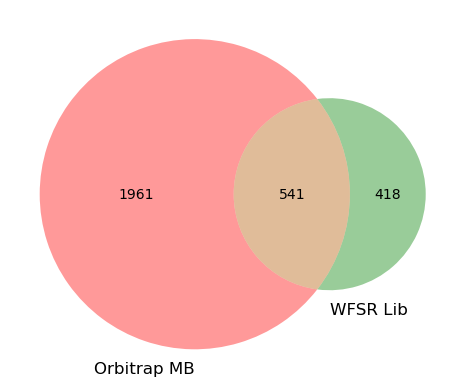

In [10]:
venn2([set(massbank_inchikeys_orbi), set(wfsr_inchikeys)], ["Orbitrap MB", "WFSR Lib"])
plt.show()

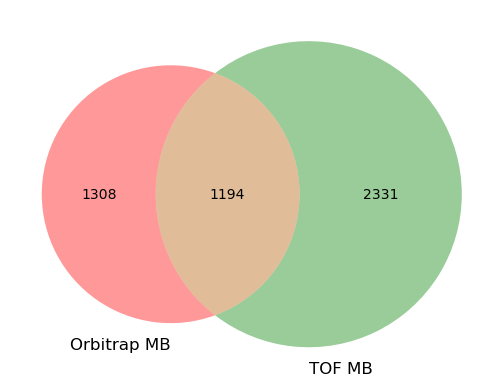

In [11]:
venn2([set(massbank_inchikeys_orbi), set(massbank_inchikeys_tof)], ["Orbitrap MB", "TOF MB"])
plt.show()

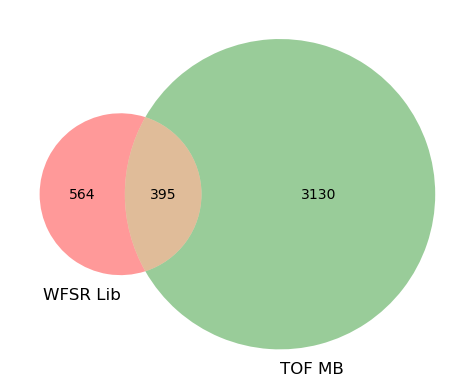

In [12]:
venn2([set(wfsr_inchikeys), set(massbank_inchikeys_tof)], ["WFSR Lib", "TOF MB"])
plt.show()

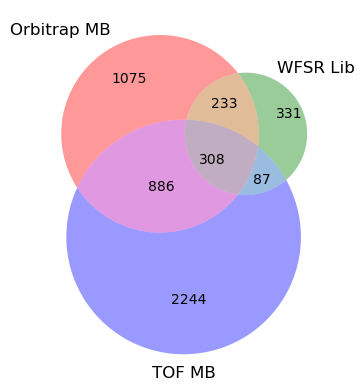

In [13]:
venn3([set(massbank_inchikeys_orbi), set(wfsr_inchikeys), set(massbank_inchikeys_tof)], ["Orbitrap MB", "WFSR Lib", "TOF MB"])
plt.show()

In [14]:
labels = venn.get_labels([set(massbank_inchikeys_orbi), set(wfsr_inchikeys), set(massbank_inchikeys_tof), set(gnps_pesticides_inchikeys), set(gnps_sciex_inchikeys)])

C:\Users\dietr004\AppData\Local\anaconda3\envs\MS2LDA_v2\Lib\site-packages\venn\_backwards_compatibility.py:15: UserWarning: `get_labels()` is retained for backwards compatibility; use `generate_petal_labels()` or the higher level `venn()` instead
  warn((


C:\Users\dietr004\AppData\Local\anaconda3\envs\MS2LDA_v2\Lib\site-packages\venn\_backwards_compatibility.py:30: UserWarning: `venn5()` is retained for backwards compatibility; use `venn()` instead
  warn((


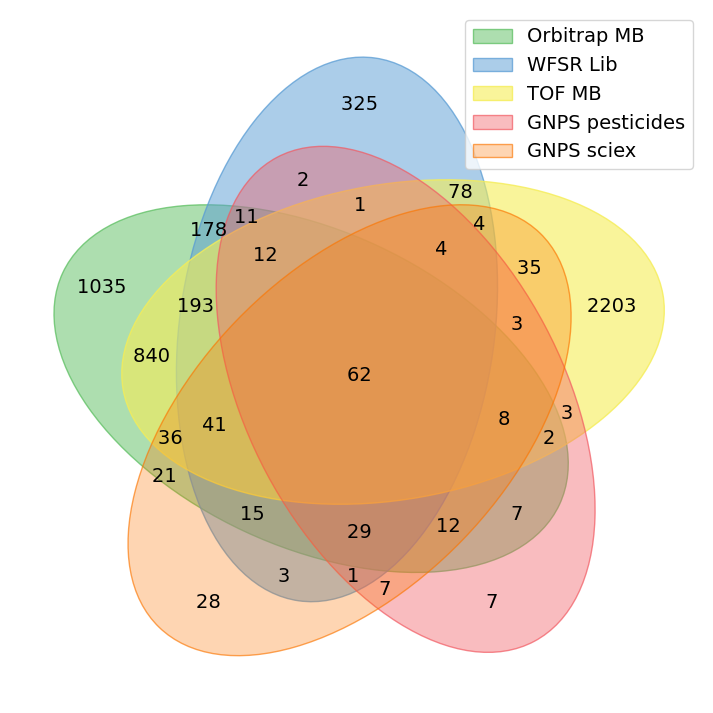

In [15]:
fig, ax = venn.venn5(labels, names=["Orbitrap MB", "WFSR Lib", "TOF MB", "GNPS pesticides", "GNPS sciex"])
plt.show()

## Library 1: WFSR + Orbitrap

In [16]:
Lib1_WFSR_mbOrbitrap = wfsr_spec + massbank_spec_orbi

In [17]:
print("Number of Spec in Lib1: ", len(Lib1_WFSR_mbOrbitrap))

Number of Spec in Lib1:  33898


In [18]:
save_as_mgf(Lib1_WFSR_mbOrbitrap, "Lib1_WFSR_mbOrbitrap.mgf")

dict_keys(['spectra'])


## Library 2: TOF

In [19]:
Lib2_mbTOF = massbank_spec_tof

In [20]:
print("Number of Spec in Lib2: ", len(Lib2_mbTOF))

Number of Spec in Lib2:  31159


In [21]:
save_as_mgf(Lib2_mbTOF, "Lib2_mbTOF.mgf")

dict_keys(['spectra'])


## Library 3: WFSR + Orbitrap + TOF

In [22]:
Lib3_WFSR_mbOrbitrap_mbTOF = wfsr_spec + massbank_spec_orbi + massbank_spec_tof + gnps_pesticides_spec + gnps_sciex_spec

In [23]:
print("Number of Spec in Lib3: ", len(Lib3_WFSR_mbOrbitrap_mbTOF))

Number of Spec in Lib3:  66024


In [24]:
save_as_mgf(Lib3_WFSR_mbOrbitrap_mbTOF, "Lib3_WFSR_mbOrbitrap_mbTOF.mgf")

dict_keys(['spectra'])


---